In [1]:
import os
import pandas as pd 
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = "Menlo"
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams.update({'font.size': 22})

#### Fingerprint ranking

Load datasets

In [2]:
auc = pd.read_csv('combined_sets/auc_mean.csv')
ef1 = pd.read_csv('combined_sets/ef1_mean.csv')
ef5 = pd.read_csv('combined_sets/ef5_mean.csv')
bedroc20 = pd.read_csv('combined_sets/bedroc20_mean.csv')
bedroc100 = pd.read_csv('combined_sets/bedroc100_mean.csv')
rie20 = pd.read_csv('combined_sets/rie20_mean.csv')
rie100 = pd.read_csv('combined_sets/rie100_mean.csv')

Rank fingerprints for all metrics

In [3]:
def calculate_ranked_list(metric_df):
    ranked = metric_df.rank(axis=1, ascending=False)
    return ranked.mean(axis=0)

# Calculate the fingerprint ranking for each metric
auc_ranked = calculate_ranked_list(auc)
ef1_ranked = calculate_ranked_list(ef1)
ef5_ranked = calculate_ranked_list(ef5)
bedroc20_ranked = calculate_ranked_list(bedroc20)
bedroc100_ranked = calculate_ranked_list(bedroc100)
rie20_ranked = calculate_ranked_list(rie20)
rie100_ranked = calculate_ranked_list(rie100)

# Combine all metrics into one dataframe
metrics_combined = pd.concat([auc_ranked, ef1_ranked, ef5_ranked, bedroc20_ranked, bedroc100_ranked, rie20_ranked, rie100_ranked], axis=1)
metrics_combined.columns = ['AUC', 'EF1', 'EF5', 'BEDROC20', 'BEDROC100', 'RIE20', 'RIE100']

Plot results

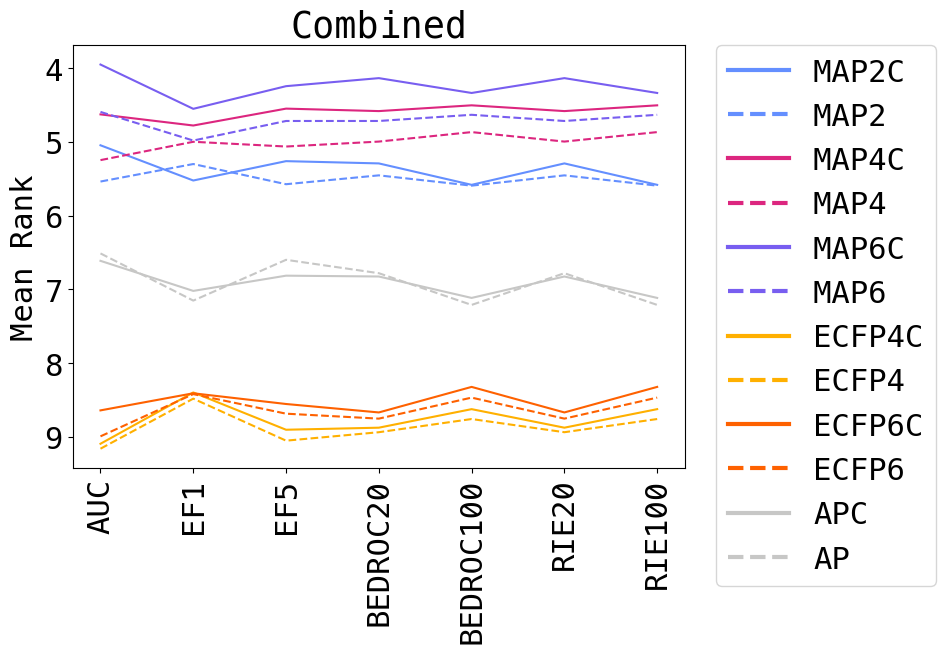

In [13]:
# Plot the fingerprint ranking for each metric in a line plot 
fig, ax = plt.subplots(figsize=(10, 7))

# Define custom colors
custom_labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']
custom_colors = ['#648FFF', '#648FFF','#DC267F', '#DC267F', '#785EF0', '#785EF0', '#FFB000', '#FFB000', '#FE6100', '#FE6100', '#C7C7C6', '#C7C7C6']
custom_linestyles = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-', '--']

# Plot each row as a line
for i, (index, row) in enumerate(metrics_combined.iterrows()):
    ax.plot(metrics_combined.columns, row, label=custom_labels[i], color=custom_colors[i], linestyle=custom_linestyles[i])

# Set title and axis labels
plt.title('Combined')
ax.set_ylabel('Mean Rank')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Invert y-axis
plt.gca().invert_yaxis()

# Add legend in the middle 
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(3.0)

# Show the plot
plt.tight_layout()
plt.savefig('plots/ranking_combined.png', dpi=1200, bbox_inches='tight')

Plot ranks for small molecules and peptides only

In [10]:
auc_small_molecules = auc.iloc[:118]
auc_peptides = auc.iloc[118:]

ef1_small_molecules = ef1.iloc[:118]
ef1_peptides = ef1.iloc[118:]

ef5_small_molecules = ef5.iloc[:118]
ef5_peptides = ef5.iloc[118:]

bedroc20_small_molecules = bedroc20.iloc[:118]
bedroc20_peptides = bedroc20.iloc[118:]

bedroc100_small_molecules = bedroc100.iloc[:118]
bedroc100_peptides = bedroc100.iloc[118:]

rie20_small_molecules = rie20.iloc[:118]
rie20_peptides = rie20.iloc[118:]

rie100_small_molecules = rie100.iloc[:118]
rie100_peptides = rie100.iloc[118:]

Small molecules

In [11]:
auc_small_molecules_ranked = calculate_ranked_list(auc_small_molecules)
ef1_small_molecules_ranked = calculate_ranked_list(ef1_small_molecules)
ef5_small_molecules_ranked = calculate_ranked_list(ef5_small_molecules)
bedroc20_small_molecules_ranked = calculate_ranked_list(bedroc20_small_molecules)
bedroc100_small_molecules_ranked = calculate_ranked_list(bedroc100_small_molecules)
rie20_small_molecules_ranked = calculate_ranked_list(rie20_small_molecules)
rie100_small_molecules_ranked = calculate_ranked_list(rie100_small_molecules)

metrics_combined_small_molecules = pd.concat([auc_small_molecules_ranked, ef1_small_molecules_ranked, ef5_small_molecules_ranked, bedroc20_small_molecules_ranked, bedroc100_small_molecules_ranked, rie20_small_molecules_ranked, rie100_small_molecules_ranked], axis=1)
metrics_combined_small_molecules.columns = ['AUC', 'EF1', 'EF5', 'BEDROC20', 'BEDROC100', 'RIE20', 'RIE100']

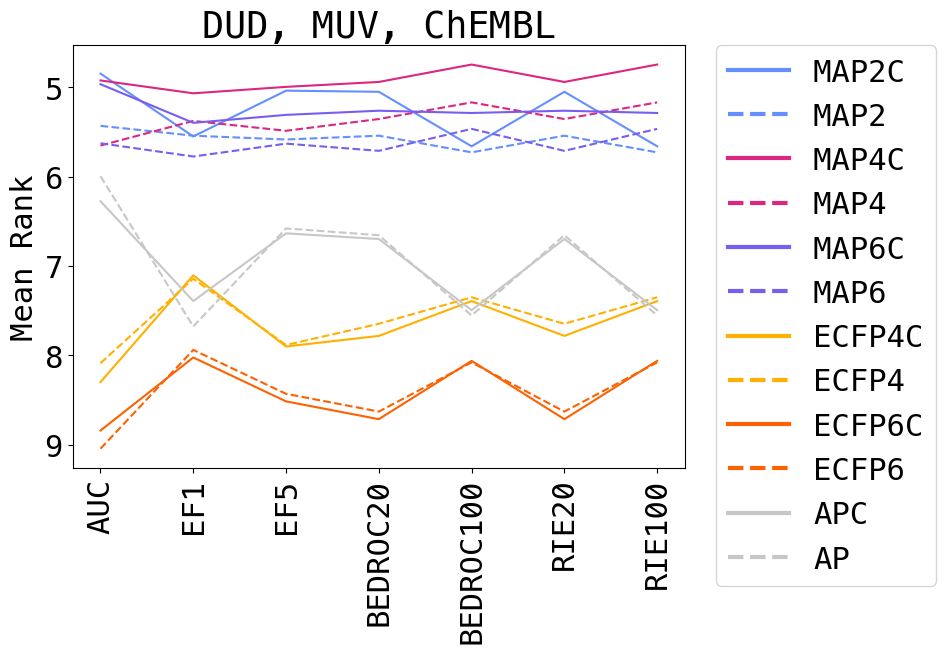

In [14]:
# Plot the fingerprint ranking for each metric in a line plot 
fig, ax = plt.subplots(figsize=(10, 7))

# Define custom colors
custom_labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']
custom_colors = ['#648FFF', '#648FFF','#DC267F', '#DC267F', '#785EF0', '#785EF0', '#FFB000', '#FFB000', '#FE6100', '#FE6100', '#C7C7C6', '#C7C7C6']
custom_linestyles = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-', '--']

# Plot each row as a line
for i, (index, row) in enumerate(metrics_combined_small_molecules.iterrows()):
    ax.plot(metrics_combined_small_molecules.columns, row, label=custom_labels[i], color=custom_colors[i], linestyle=custom_linestyles[i])

# Set title and axis labels
plt.title('DUD, MUV, ChEMBL')
ax.set_ylabel('Mean Rank')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Invert y-axis
plt.gca().invert_yaxis()

# Add legend
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(3.0)

# Show the plot
plt.tight_layout()
plt.savefig('plots/ranking_small.png', dpi=1200, bbox_inches='tight')

Peptides

In [15]:
auc_peptides_ranked = calculate_ranked_list(auc_peptides)
ef1_peptides_ranked = calculate_ranked_list(ef1_peptides)
ef5_peptides_ranked = calculate_ranked_list(ef5_peptides)
bedroc20_peptides_ranked = calculate_ranked_list(bedroc20_peptides)
bedroc100_peptides_ranked = calculate_ranked_list(bedroc100_peptides)
rie20_peptides_ranked = calculate_ranked_list(rie20_peptides)
rie100_peptides_ranked = calculate_ranked_list(rie100_peptides)

metrics_combined_peptides = pd.concat([auc_peptides_ranked, ef1_peptides_ranked, ef5_peptides_ranked, bedroc20_peptides_ranked, bedroc100_peptides_ranked, rie20_peptides_ranked, rie100_peptides_ranked], axis=1)
metrics_combined_peptides.columns = ['AUC', 'EF1', 'EF5', 'BEDROC20', 'BEDROC100', 'RIE20', 'RIE100']

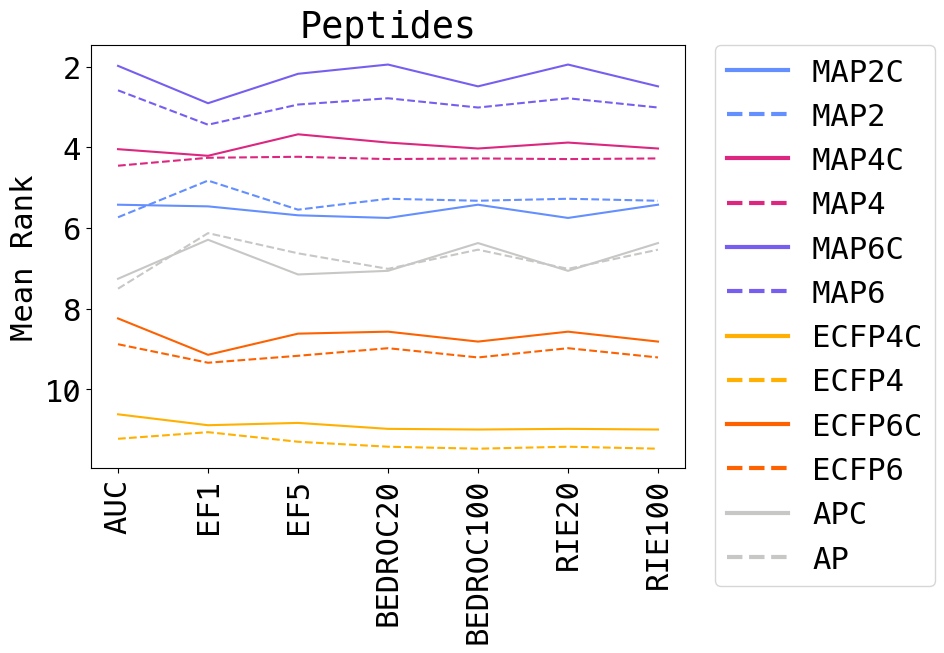

In [16]:
# Plot the fingerprint ranking for each metric in a line plot 
fig, ax = plt.subplots(figsize=(10, 7))

# Define custom colors
custom_labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']
custom_colors = ['#648FFF', '#648FFF','#DC267F', '#DC267F', '#785EF0', '#785EF0', '#FFB000', '#FFB000', '#FE6100', '#FE6100', '#C7C7C6', '#C7C7C6']
custom_linestyles = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-', '--']

# Plot each row as a line
for i, (index, row) in enumerate(metrics_combined_peptides.iterrows()):
    ax.plot(metrics_combined_peptides.columns, row, label=custom_labels[i], color=custom_colors[i], linestyle=custom_linestyles[i])

# Set title and axis labels
plt.title('Peptides')
ax.set_ylabel('Mean Rank')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Invert y-axis
plt.gca().invert_yaxis()

# Add legend
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(3.0)

# Show the plot
plt.tight_layout()
plt.savefig('plots/ranking_peptides.png', dpi=1200, bbox_inches='tight')

#### Combined plots

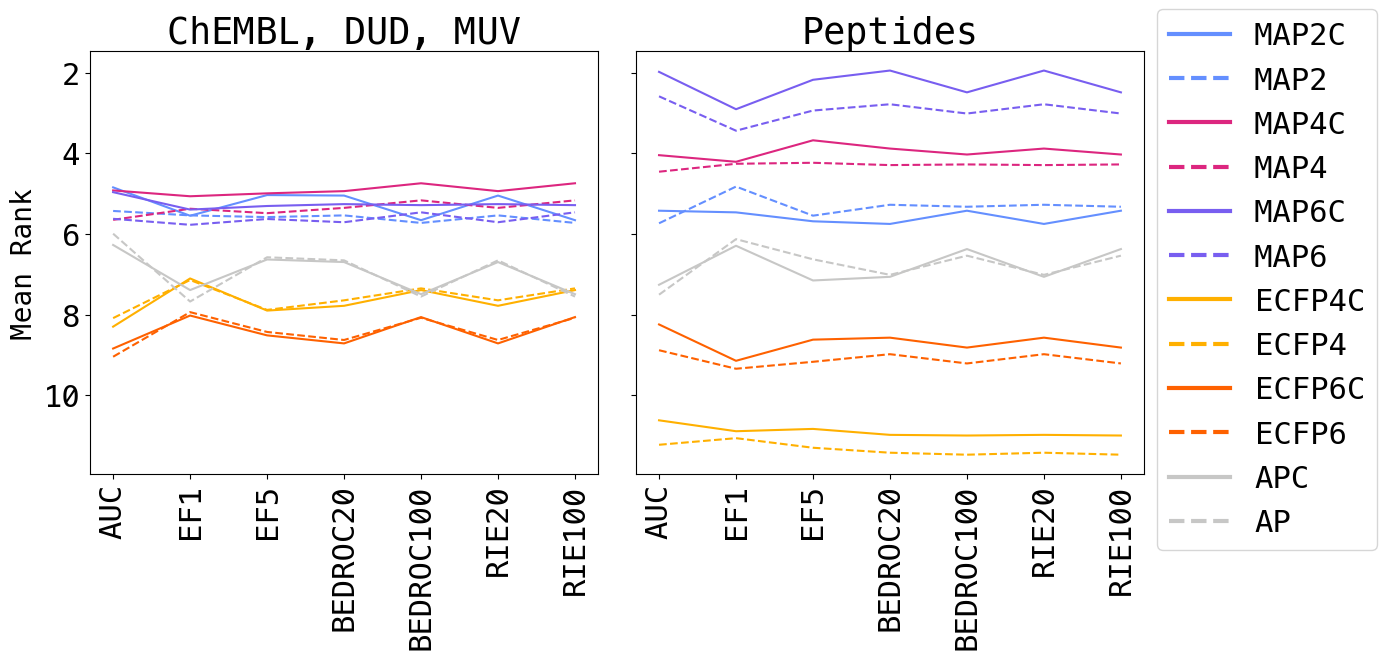

In [49]:
# Create a single figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 7), sharey=True)

# Combine sets
metrics_all = [metrics_combined_small_molecules, metrics_combined_peptides]

# List of titles for subplots
subplot_titles = ['ChEMBL, DUD, MUV', 'Peptides']

# Iterate through subplots and data
for i, ax in enumerate(axes):
    metrics = metrics_all[i]
    for j, (index, row) in enumerate(metrics.iterrows()):
        ax.plot(metrics.columns, row, label=custom_labels[j], color=custom_colors[j], linestyle=custom_linestyles[j])

    # Set title and axis labels for each subplot
    ax.set_title(subplot_titles[i])

    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=90)

    # Invert y-axis
    ax.invert_yaxis()

    # Add y-axis label only for the left plot
    if i == 0:
        ax.set_ylabel('Mean Rank', fontsize=20)

# Add a single legend for all subplots
handles, labels = ax.get_legend_handles_labels()
lgd = fig.legend(handles, labels, bbox_to_anchor=(1.075, 0.575), loc='center', borderaxespad=0.)

# Invert y-axis
plt.gca().invert_yaxis()

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(3.0)

# Adjust subplot layout
plt.tight_layout()

# Save the plot
plt.savefig('plots/ranking_figures_combined.png', dpi=1200, bbox_inches='tight')

#### AUCs

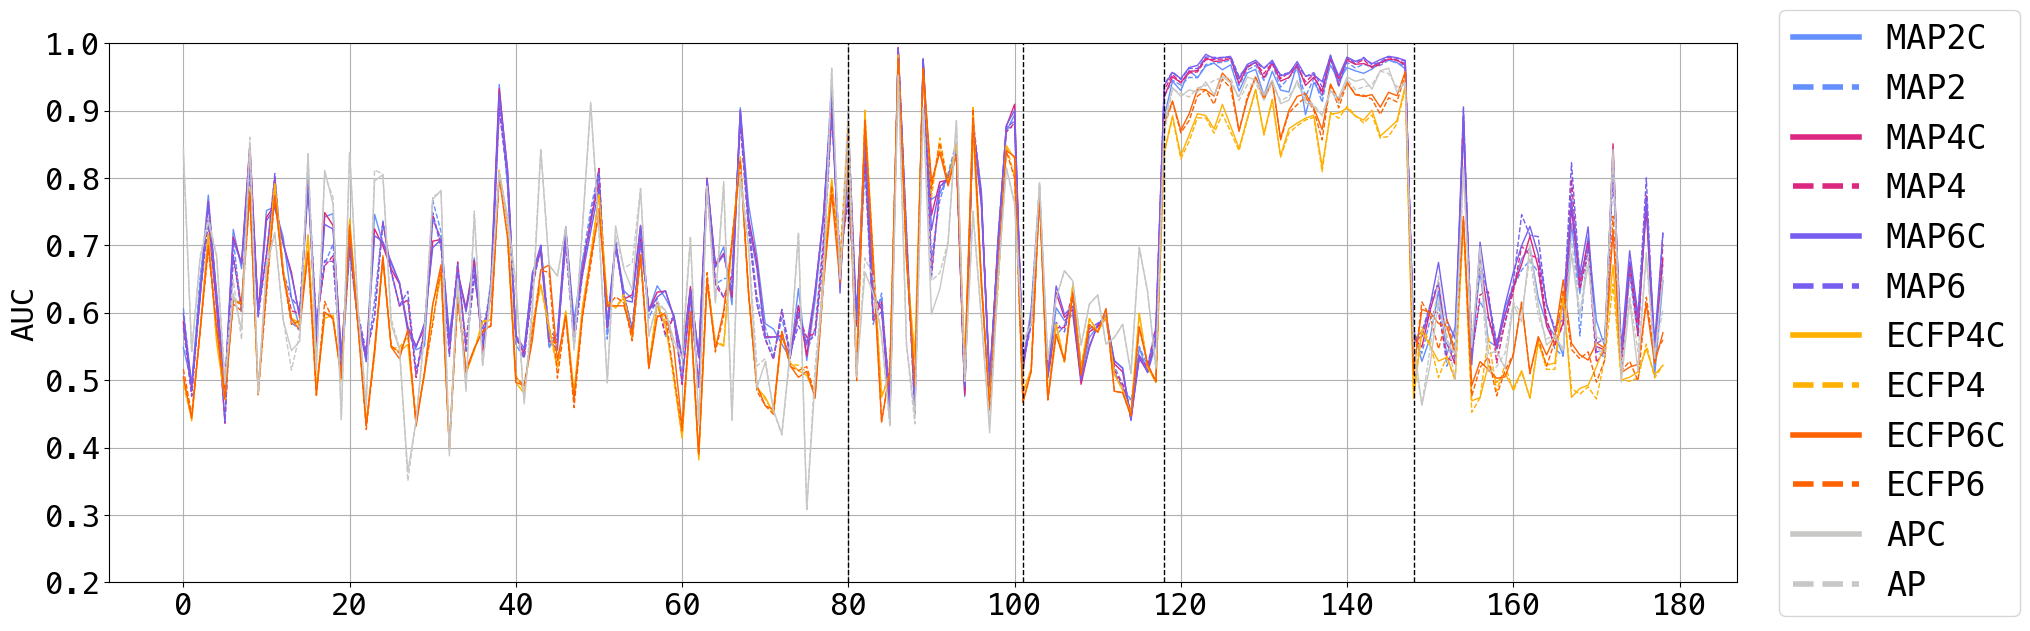

In [54]:
column = 'auc_mean'
datasets = ['ChEMBL', 'DUD', 'MUV', 'PeptidesM', 'Peptides']
custom_labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']
custom_colors = ['#648FFF', '#648FFF','#DC267F', '#DC267F', '#785EF0', '#785EF0', '#FFB000', '#FFB000', '#FE6100', '#FE6100', '#C7C7C6', '#C7C7C6']
custom_linestyles = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-', '--']

# Empty dataframe
df_plot = pd.DataFrame(columns=['map2c', 'map2', 'map4c', 'map4', 'map6c', 'map6', 'ecfp4c', 'ecfp4', 'ecfp6c', 'ecfp6', 'apc', 'ap'])

for dataset in datasets:
    dataset_path = f'../validation/{dataset}'

    for file in os.listdir(dataset_path):
            data = pd.read_csv(os.path.join(dataset_path, file))[column].values
            df_plot.loc[len(df_plot)] = data

plt.figure(figsize=(21, 7))
for i, column in enumerate(df_plot.columns):
    plt.plot(df_plot[column].values, label=custom_labels[i], linewidth=1, color=custom_colors[i], linestyle=custom_linestyles[i])

# Add vertical lines to indicate the different datasets
plt.axvline(x=80, color='black', linestyle='--', linewidth=1)
plt.axvline(x=101, color='black', linestyle='--', linewidth=1)
plt.axvline(x=118, color='black', linestyle='--', linewidth=1)
plt.axvline(x=148, color='black', linestyle='--', linewidth=1)

plt.ylabel('AUC')
plt.ylim(0.2, 1)
lgd = plt.legend(bbox_to_anchor=(1.1, 0.5), loc='center', borderaxespad=0., fontsize=24)
plt.grid(True)

# Set x-Axis ticks 
plt.xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180], ['0', '20', '40', '60', '80', '100', '120', '140', '160', '180'])

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(4.0)

plt.savefig('plots/aucs.png', dpi=1200, bbox_inches='tight')

#### EF1s

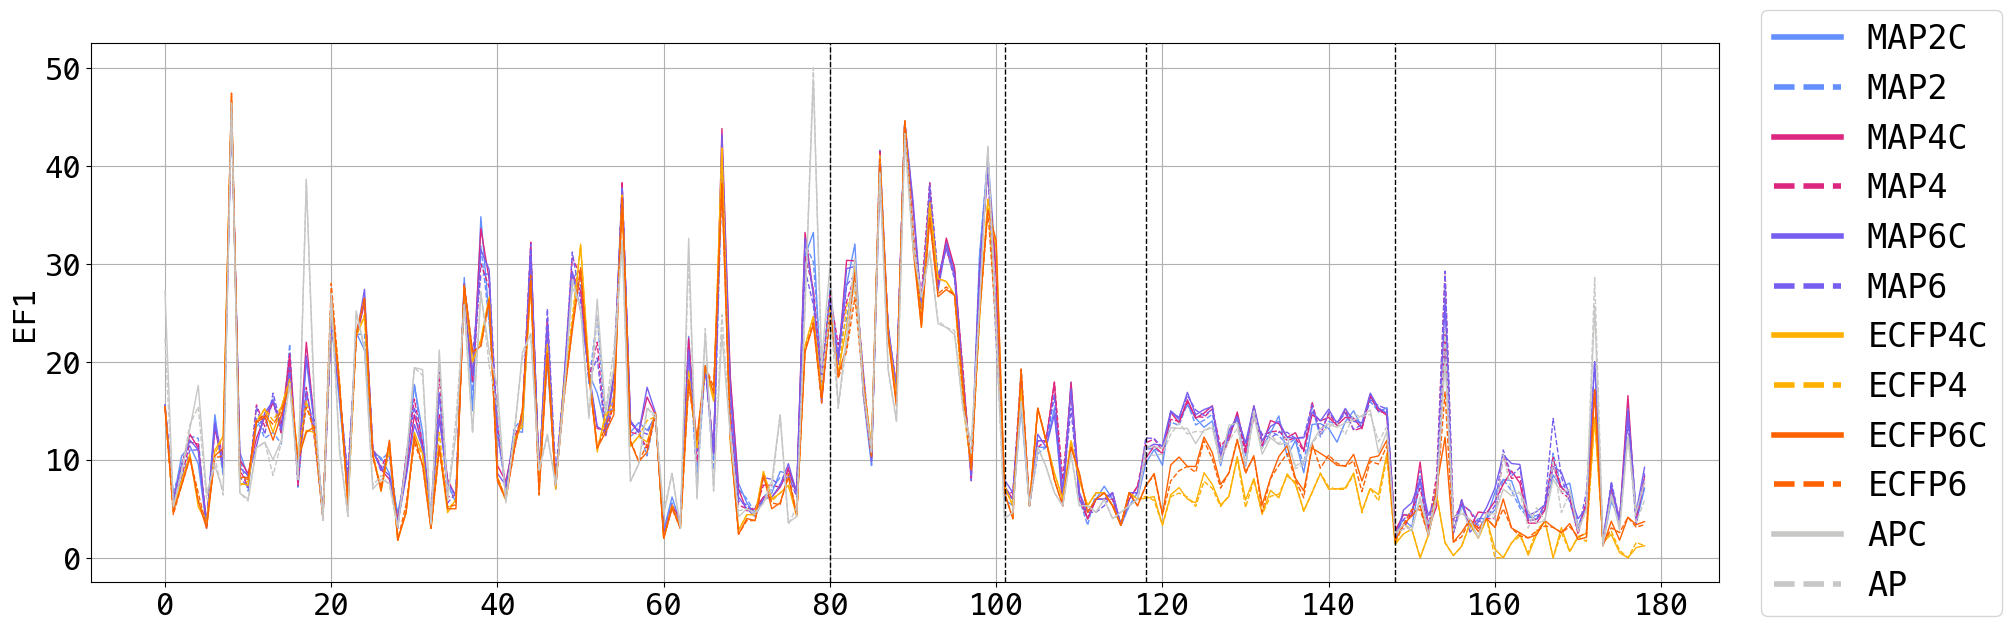

In [55]:
column = 'ef1_mean'
datasets = ['ChEMBL', 'DUD', 'MUV', 'PeptidesM', 'Peptides']
custom_labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']
custom_colors = ['#648FFF', '#648FFF','#DC267F', '#DC267F', '#785EF0', '#785EF0', '#FFB000', '#FFB000', '#FE6100', '#FE6100', '#C7C7C6', '#C7C7C6']
custom_linestyles = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-', '--']

# Empty dataframe
df_plot = pd.DataFrame(columns=['map2c', 'map2', 'map4c', 'map4', 'map6c', 'map6', 'ecfp4c', 'ecfp4', 'ecfp6c', 'ecfp6', 'apc', 'ap'])

for dataset in datasets:
    dataset_path = f'../validation/{dataset}'

    for file in os.listdir(dataset_path):
            data = pd.read_csv(os.path.join(dataset_path, file))[column].values
            df_plot.loc[len(df_plot)] = data

plt.figure(figsize=(21, 7))
for i, column in enumerate(df_plot.columns):
    plt.plot(df_plot[column].values, label=custom_labels[i], linewidth=1, color=custom_colors[i], linestyle=custom_linestyles[i])

# Add vertical lines to indicate the different datasets
plt.axvline(x=80, color='black', linestyle='--', linewidth=1)
plt.axvline(x=101, color='black', linestyle='--', linewidth=1)
plt.axvline(x=118, color='black', linestyle='--', linewidth=1)
plt.axvline(x=148, color='black', linestyle='--', linewidth=1)

plt.ylabel('EF1')
lgd = plt.legend(bbox_to_anchor=(1.1, 0.5), loc='center', borderaxespad=0., fontsize=24)
plt.grid(True)

# Set x-Axis ticks 
plt.xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180], ['0', '20', '40', '60', '80', '100', '120', '140', '160', '180'])

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(4.0)

plt.savefig('plots/ef1s.png', dpi=1200, bbox_inches='tight')

#### EF5s

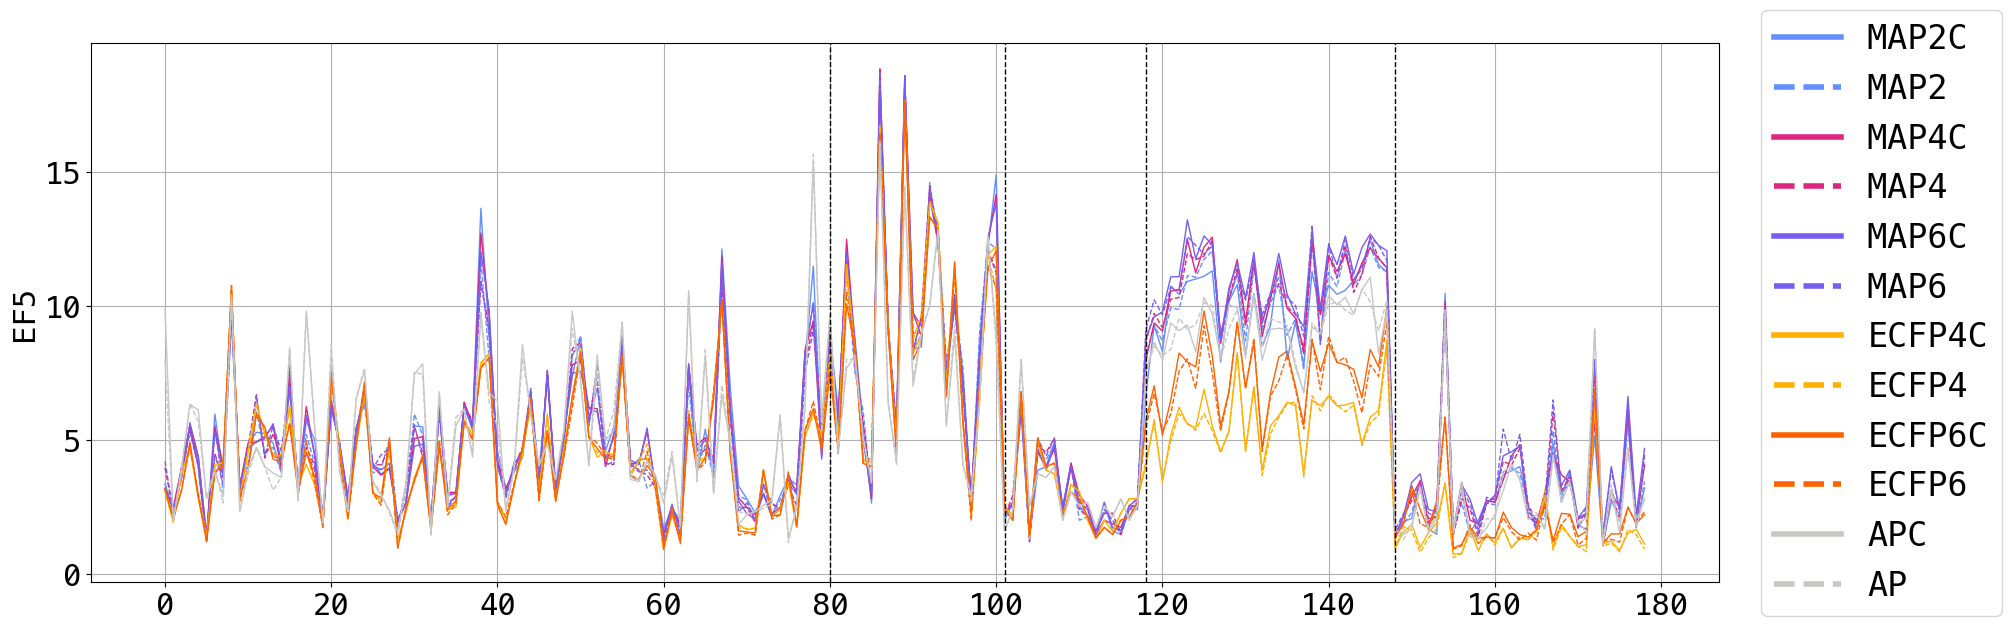

In [56]:
column = 'ef5_mean'
datasets = ['ChEMBL', 'DUD', 'MUV', 'PeptidesM', 'Peptides']
custom_labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']
custom_colors = ['#648FFF', '#648FFF','#DC267F', '#DC267F', '#785EF0', '#785EF0', '#FFB000', '#FFB000', '#FE6100', '#FE6100', '#C7C7C6', '#C7C7C6']
custom_linestyles = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-', '--']

# Empty dataframe
df_plot = pd.DataFrame(columns=['map2c', 'map2', 'map4c', 'map4', 'map6c', 'map6', 'ecfp4c', 'ecfp4', 'ecfp6c', 'ecfp6', 'apc', 'ap'])

for dataset in datasets:
    dataset_path = f'../validation/{dataset}'

    for file in os.listdir(dataset_path):
            data = pd.read_csv(os.path.join(dataset_path, file))[column].values
            df_plot.loc[len(df_plot)] = data

plt.figure(figsize=(21, 7))
for i, column in enumerate(df_plot.columns):
    plt.plot(df_plot[column].values, label=custom_labels[i], linewidth=1, color=custom_colors[i], linestyle=custom_linestyles[i])

# Add vertical lines to indicate the different datasets
plt.axvline(x=80, color='black', linestyle='--', linewidth=1)
plt.axvline(x=101, color='black', linestyle='--', linewidth=1)
plt.axvline(x=118, color='black', linestyle='--', linewidth=1)
plt.axvline(x=148, color='black', linestyle='--', linewidth=1)

plt.ylabel('EF5')
lgd = plt.legend(bbox_to_anchor=(1.1, 0.5), loc='center', borderaxespad=0., fontsize=24)
plt.grid(True)

# Set x-Axis ticks 
plt.xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180], ['0', '20', '40', '60', '80', '100', '120', '140', '160', '180'])

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(4.0)

plt.savefig('plots/ef5s.png', dpi=1200, bbox_inches='tight')

#### BEDROC 20

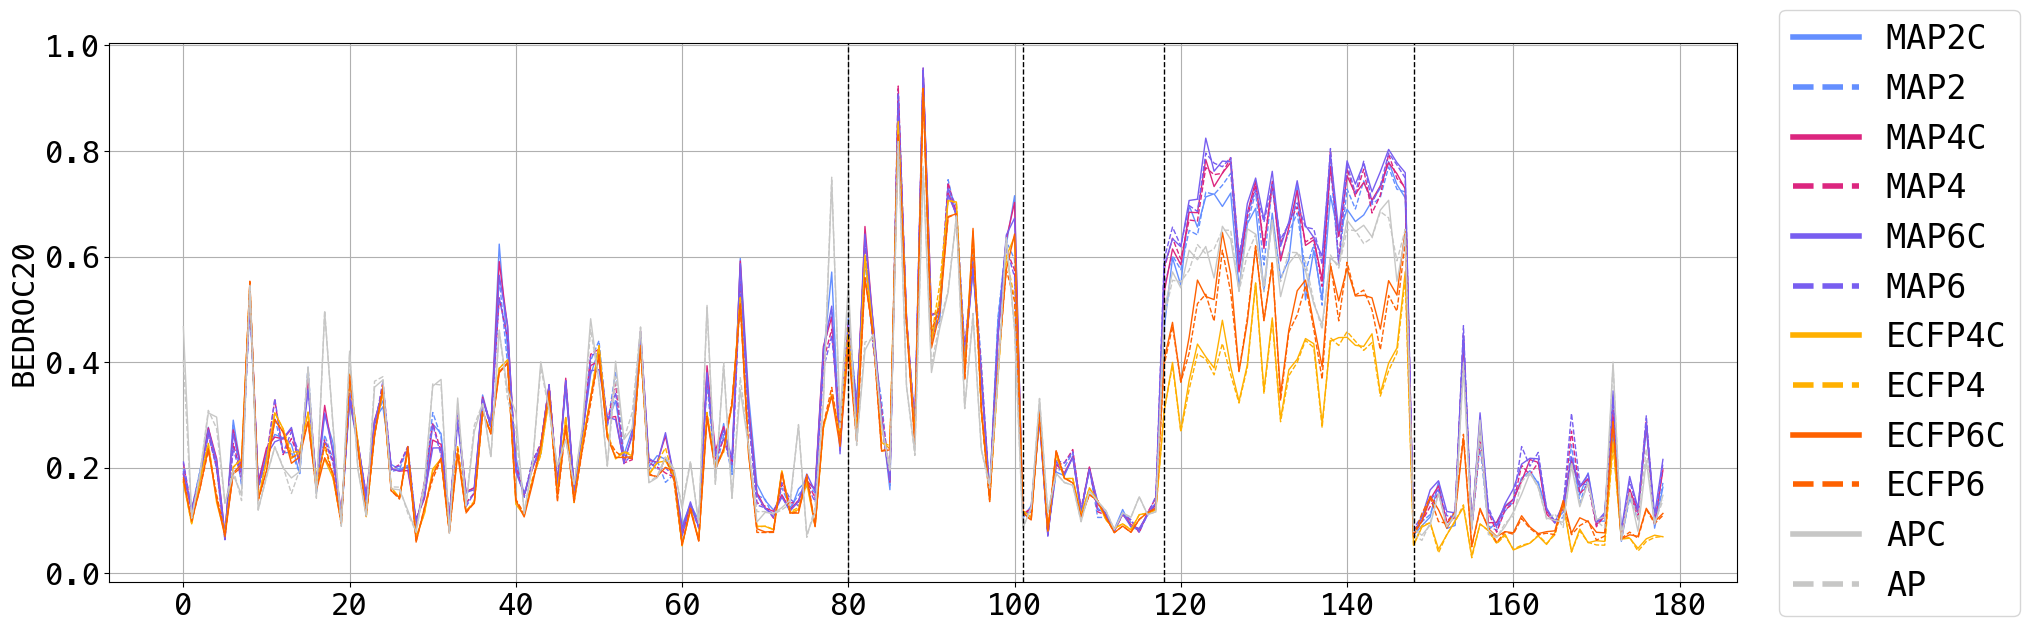

In [57]:
column = 'bedroc20_mean'
datasets = ['ChEMBL', 'DUD', 'MUV', 'PeptidesM', 'Peptides']
custom_labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']
custom_colors = ['#648FFF', '#648FFF','#DC267F', '#DC267F', '#785EF0', '#785EF0', '#FFB000', '#FFB000', '#FE6100', '#FE6100', '#C7C7C6', '#C7C7C6']
custom_linestyles = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-', '--']

# Empty dataframe
df_plot = pd.DataFrame(columns=['map2c', 'map2', 'map4c', 'map4', 'map6c', 'map6', 'ecfp4c', 'ecfp4', 'ecfp6c', 'ecfp6', 'apc', 'ap'])

for dataset in datasets:
    dataset_path = f'../validation/{dataset}'

    for file in os.listdir(dataset_path):
            data = pd.read_csv(os.path.join(dataset_path, file))[column].values
            df_plot.loc[len(df_plot)] = data

plt.figure(figsize=(21, 7))
for i, column in enumerate(df_plot.columns):
    plt.plot(df_plot[column].values, label=custom_labels[i], linewidth=1, color=custom_colors[i], linestyle=custom_linestyles[i])

# Add vertical lines to indicate the different datasets
plt.axvline(x=80, color='black', linestyle='--', linewidth=1)
plt.axvline(x=101, color='black', linestyle='--', linewidth=1)
plt.axvline(x=118, color='black', linestyle='--', linewidth=1)
plt.axvline(x=148, color='black', linestyle='--', linewidth=1)

plt.ylabel('BEDROC20')
lgd = plt.legend(bbox_to_anchor=(1.1, 0.5), loc='center', borderaxespad=0., fontsize=24)
plt.grid(True)

# Set x-Axis ticks 
plt.xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180], ['0', '20', '40', '60', '80', '100', '120', '140', '160', '180'])

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(4.0)

plt.savefig('plots/bedroc20s.png', dpi=1200, bbox_inches='tight')

#### BEDROC 100

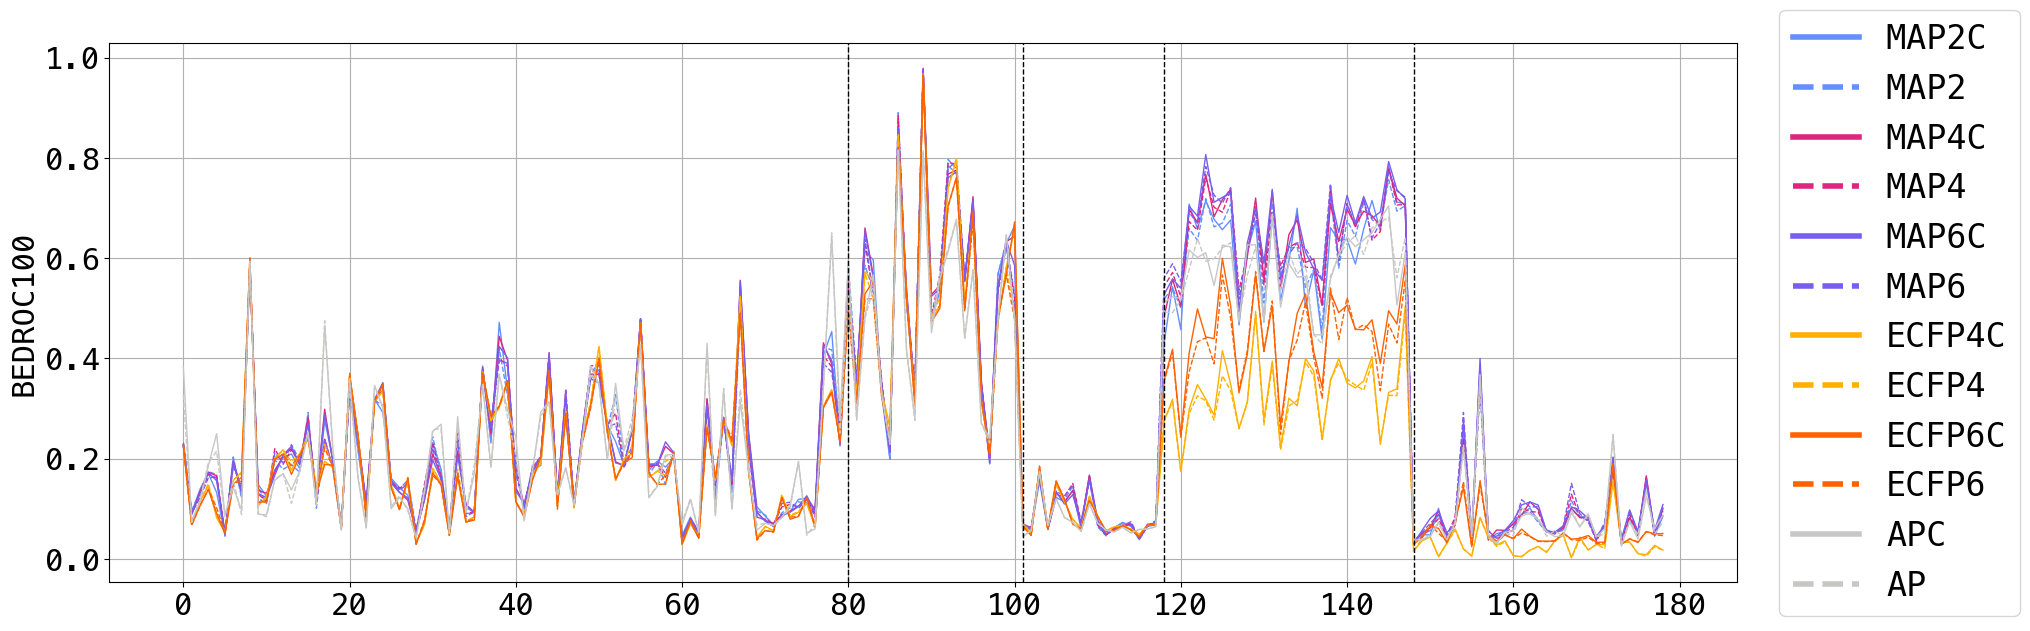

In [58]:
column = 'bedroc100_mean'
datasets = ['ChEMBL', 'DUD', 'MUV', 'PeptidesM', 'Peptides']
custom_labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']
custom_colors = ['#648FFF', '#648FFF','#DC267F', '#DC267F', '#785EF0', '#785EF0', '#FFB000', '#FFB000', '#FE6100', '#FE6100', '#C7C7C6', '#C7C7C6']
custom_linestyles = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-', '--']

# Empty dataframe
df_plot = pd.DataFrame(columns=['map2c', 'map2', 'map4c', 'map4', 'map6c', 'map6', 'ecfp4c', 'ecfp4', 'ecfp6c', 'ecfp6', 'apc', 'ap'])

for dataset in datasets:
    dataset_path = f'../validation/{dataset}'

    for file in os.listdir(dataset_path):
            data = pd.read_csv(os.path.join(dataset_path, file))[column].values
            df_plot.loc[len(df_plot)] = data

plt.figure(figsize=(21, 7))
for i, column in enumerate(df_plot.columns):
    plt.plot(df_plot[column].values, label=custom_labels[i], linewidth=1, color=custom_colors[i], linestyle=custom_linestyles[i])

# Add vertical lines to indicate the different datasets
plt.axvline(x=80, color='black', linestyle='--', linewidth=1)
plt.axvline(x=101, color='black', linestyle='--', linewidth=1)
plt.axvline(x=118, color='black', linestyle='--', linewidth=1)
plt.axvline(x=148, color='black', linestyle='--', linewidth=1)

plt.ylabel('BEDROC100')
lgd = plt.legend(bbox_to_anchor=(1.1, 0.5), loc='center', borderaxespad=0., fontsize=24)
plt.grid(True)

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(4.0)

# Set x-Axis ticks 
plt.xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180], ['0', '20', '40', '60', '80', '100', '120', '140', '160', '180'])

plt.savefig('plots/bedroc100s.png', dpi=1200, bbox_inches='tight')

### RIE 20

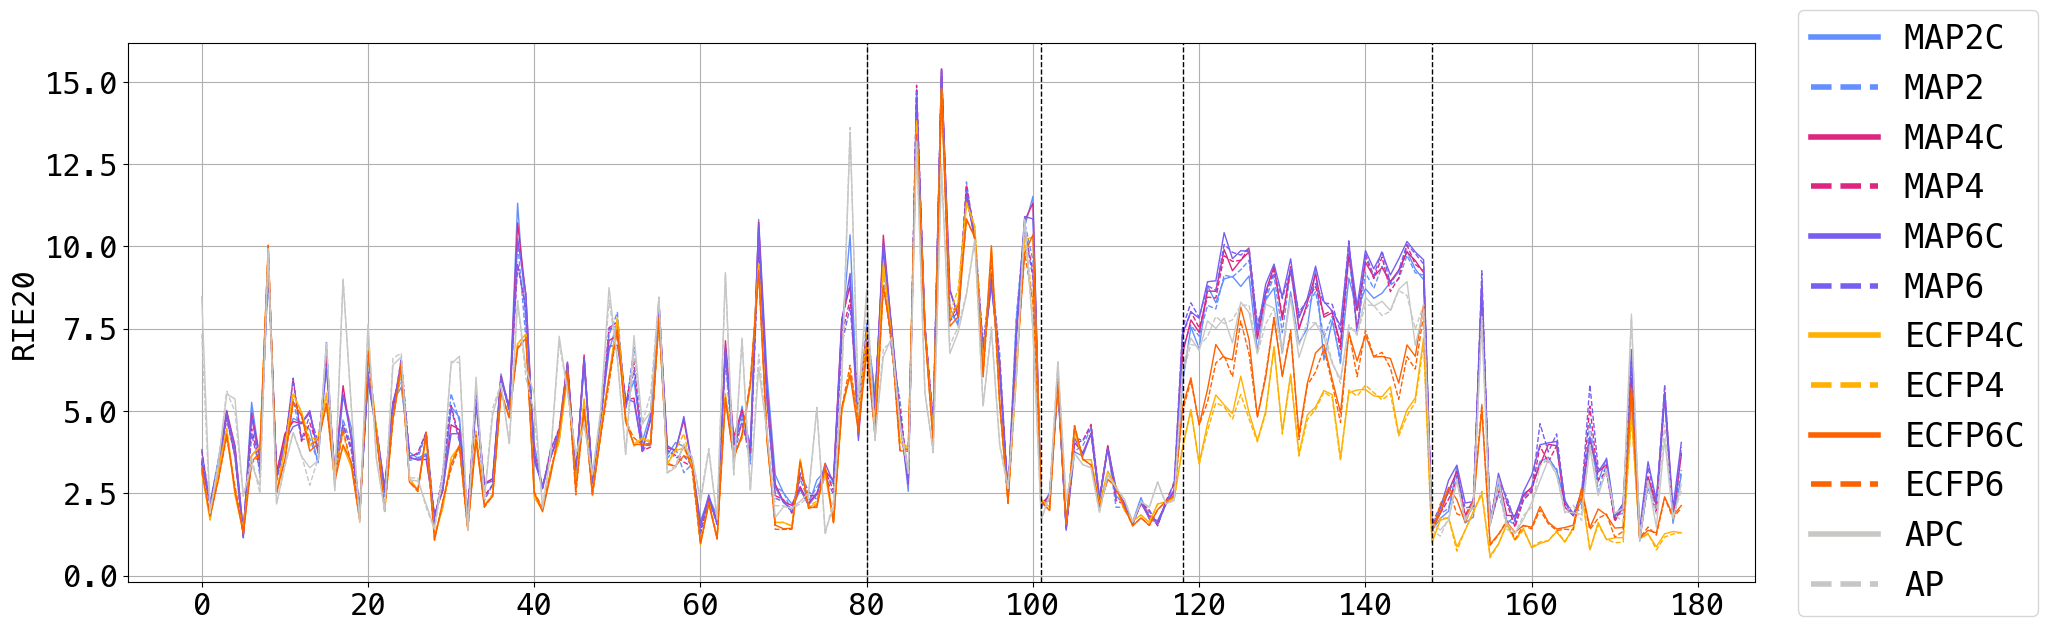

In [59]:
column = 'rie20_mean'
datasets = ['ChEMBL', 'DUD', 'MUV', 'PeptidesM', 'Peptides']
custom_labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']
custom_colors = ['#648FFF', '#648FFF','#DC267F', '#DC267F', '#785EF0', '#785EF0', '#FFB000', '#FFB000', '#FE6100', '#FE6100', '#C7C7C6', '#C7C7C6']
custom_linestyles = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-', '--']

# Empty dataframe
df_plot = pd.DataFrame(columns=['map2c', 'map2', 'map4c', 'map4', 'map6c', 'map6', 'ecfp4c', 'ecfp4', 'ecfp6c', 'ecfp6', 'apc', 'ap'])

for dataset in datasets:
    dataset_path = f'../validation/{dataset}'

    for file in os.listdir(dataset_path):
            data = pd.read_csv(os.path.join(dataset_path, file))[column].values
            df_plot.loc[len(df_plot)] = data

plt.figure(figsize=(21, 7))
for i, column in enumerate(df_plot.columns):
    plt.plot(df_plot[column].values, label=custom_labels[i], linewidth=1, color=custom_colors[i], linestyle=custom_linestyles[i])

# Add vertical lines to indicate the different datasets
plt.axvline(x=80, color='black', linestyle='--', linewidth=1)
plt.axvline(x=101, color='black', linestyle='--', linewidth=1)
plt.axvline(x=118, color='black', linestyle='--', linewidth=1)
plt.axvline(x=148, color='black', linestyle='--', linewidth=1)

plt.ylabel('RIE20')
lgd = plt.legend(bbox_to_anchor=(1.1, 0.5), loc='center', borderaxespad=0., fontsize=24)
plt.grid(True)

# Set x-Axis ticks 
plt.xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180], ['0', '20', '40', '60', '80', '100', '120', '140', '160', '180'])

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(4.0)

plt.savefig('plots/rie20s.png', dpi=1200, bbox_inches='tight')

RIE 100

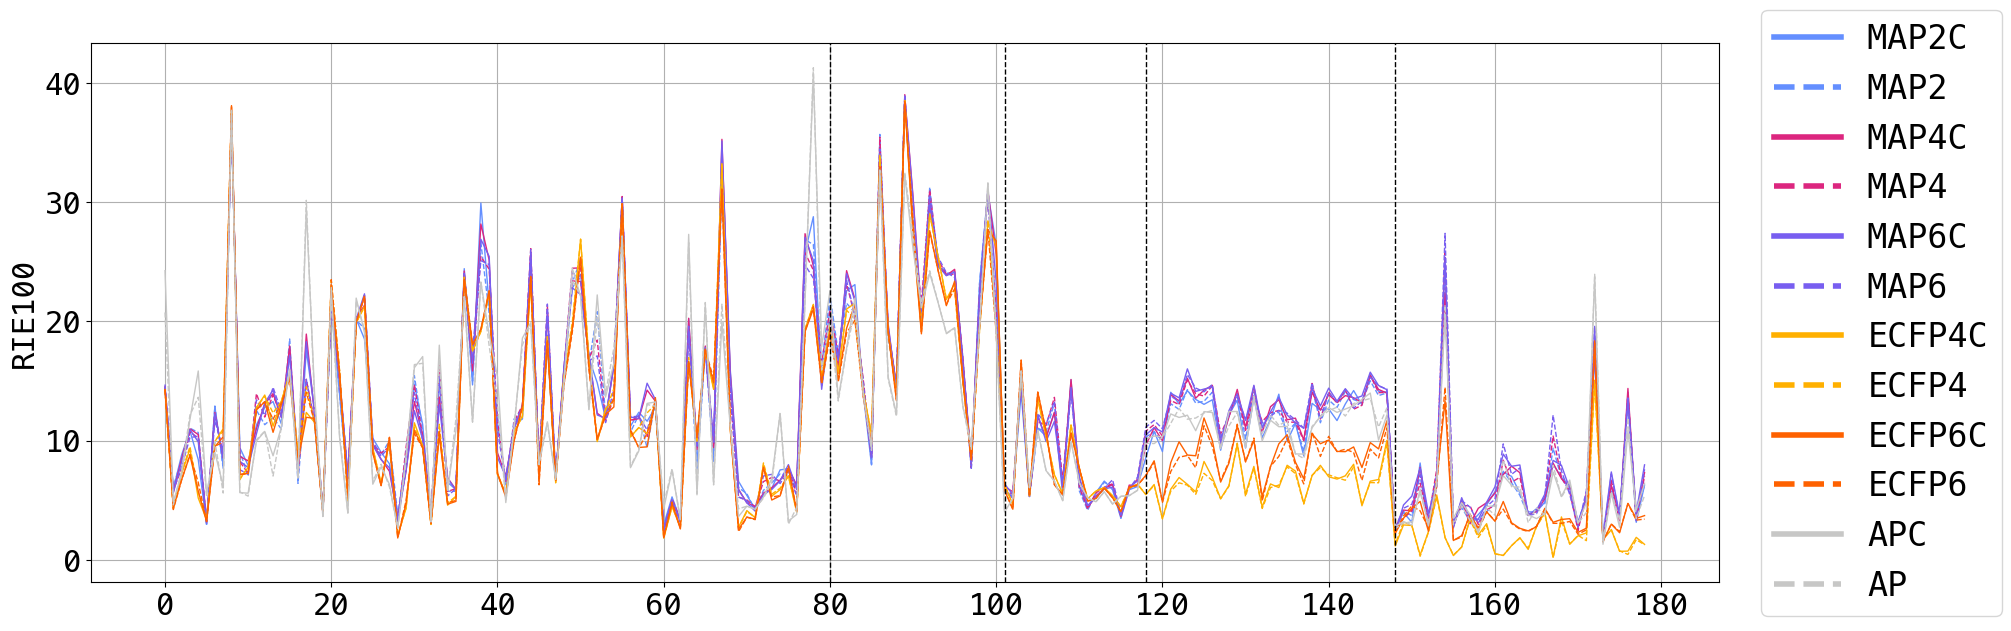

In [60]:
column = 'rie100_mean'
datasets = ['ChEMBL', 'DUD', 'MUV', 'PeptidesM', 'Peptides']
custom_labels = ['MAP2C', 'MAP2', 'MAP4C', 'MAP4', 'MAP6C', 'MAP6', 'ECFP4C', 'ECFP4', 'ECFP6C', 'ECFP6', 'APC', 'AP']
custom_colors = ['#648FFF', '#648FFF','#DC267F', '#DC267F', '#785EF0', '#785EF0', '#FFB000', '#FFB000', '#FE6100', '#FE6100', '#C7C7C6', '#C7C7C6']
custom_linestyles = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-', '--']

# Empty dataframe
df_plot = pd.DataFrame(columns=['map2c', 'map2', 'map4c', 'map4', 'map6c', 'map6', 'ecfp4c', 'ecfp4', 'ecfp6c', 'ecfp6', 'apc', 'ap'])

for dataset in datasets:
    dataset_path = f'../validation/{dataset}'

    for file in os.listdir(dataset_path):
            data = pd.read_csv(os.path.join(dataset_path, file))[column].values
            df_plot.loc[len(df_plot)] = data

plt.figure(figsize=(21, 7))
for i, column in enumerate(df_plot.columns):
    plt.plot(df_plot[column].values, label=custom_labels[i], linewidth=1, color=custom_colors[i], linestyle=custom_linestyles[i])

# Add vertical lines to indicate the different datasets
plt.axvline(x=80, color='black', linestyle='--', linewidth=1)
plt.axvline(x=101, color='black', linestyle='--', linewidth=1)
plt.axvline(x=118, color='black', linestyle='--', linewidth=1)
plt.axvline(x=148, color='black', linestyle='--', linewidth=1)

plt.ylabel('RIE100')
lgd = plt.legend(bbox_to_anchor=(1.1, 0.5), loc='center', borderaxespad=0., fontsize=24)
plt.grid(True)

# Set x-Axis ticks 
plt.xticks([0, 20, 40, 60, 80, 100, 120, 140, 160, 180], ['0', '20', '40', '60', '80', '100', '120', '140', '160', '180'])

# Change the line width for the legend
for line in lgd.get_lines():
    line.set_linewidth(4.0)

plt.savefig('plots/rie100s.png', dpi=1200, bbox_inches='tight')